## Интеллектуальный анализ данных – весна 2025
## Домашнее задание 4: kNN. Линейные модели. Работа с признаками

Правила:

* Домашнее задание оценивается в 10 баллов.

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

* Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.  

* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

### Задание 1:  Визуализация решающих поверхностей в kNN.

В этом задании мы изобразим решающую поверхность для классификатора kNN, чтобы наглядно увидеть, как классификатор принимает решения для новых объектов. Для простоты будем работать с усеченным датасетом `Palmer Penguins`, содержащим информацию о характеристиках трех видов пингвинов: `Adelie`, `Chinstrap` и `Gentoo`:



*   Species — вид пингвина (целевая переменная).
*   Island — остров, на котором была сделана запись.
*   Clutch Completion — завершенность кладки яиц.
*   Date Egg — закодированная дата откладки яиц (число дней от самой ранней даты в данных).
*   Culmen Length (mm) — длина клюва.
*   Culmen Depth (mm) — глубина клюва.
*   Flipper Length (mm) — длина ласт.
*   Body Mass (g) — масса тела в граммах.
*   Sex — пол особи.
*   Delta 15 N (o/oo) и Delta 13 C (o/oo) — изотопные значения, характеризующие пищевые предпочтения.

Описание полного набора данных и дополнительную информацию о проекте можно найти [здесь](https://allisonhorst.github.io/palmerpenguins/index.html) и [здесь](https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data?resource=download).

![Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/reference/figures/lter_penguins.png)



In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [90]:
data = pd.read_csv('penguins_data.csv')
data.head(10)

,Species,Island,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
0,Chinstrap,Dream,Yes,382,50.9,19.1,196.0,3550.0,MALE,10.02372,-24.86594
1,Chinstrap,Dream,Yes,741,45.2,17.8,198.0,3950.0,FEMALE,8.88942,-24.49433
2,Gentoo,Biscoe,Yes,744,46.5,13.5,210.0,4550.0,FEMALE,7.99530,-25.32829
3,Chinstrap,Dream,Yes,10,45.2,16.6,191.0,3250.0,FEMALE,9.62357,-24.78984
4,Gentoo,Biscoe,Yes,13,48.4,14.4,203.0,4625.0,FEMALE,8.16582,-26.13971
5,Gentoo,Biscoe,Yes,22,48.1,15.1,209.0,5500.0,MALE,8.45738,-26.22664
6,Gentoo,Biscoe,Yes,13,51.1,16.5,225.0,5250.0,MALE,8.20660,-26.36863
7,Gentoo,Biscoe,No,392,42.7,13.7,208.0,3950.0,FEMALE,8.14567,-26.59467
8,Adelie,Biscoe,Yes,14,39.6,20.7,191.0,3900.0,FEMALE,8.80967,-26.78958
9,Gentoo,Biscoe,Yes,735,46.1,13.2,211.0,4500.0,FEMALE,7.99300,-25.51390


**Задача 1.1 (0.5 балла)** Есть ли в наборе данных пропущенные значения? Если да, то удалите их. Есть ли в наборе данных категориальные признаки? Если да, то закодируйте их самым оптимальным способом. Аргументируйте свой выбор.

In [91]:
data.describe()

,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo)
count,344.000000,342.000000,342.000000,342.000000,342.000000,330.000000,331.000000
mean,368.843023,43.921930,17.151170,200.915205,4201.754386,8.733382,-25.686292
std,298.826907,5.459584,1.974793,14.061714,801.954536,0.551770,0.793961
min,0.000000,32.100000,13.100000,172.000000,2700.000000,7.632200,-27.018540
25%,15.000000,39.225000,15.600000,190.000000,3550.000000,8.299890,-26.320305
50%,387.000000,44.450000,17.300000,197.000000,4050.000000,8.652405,-25.833520
75%,734.000000,48.500000,18.700000,213.000000,4750.000000,9.172123,-25.062050
max,753.000000,59.600000,21.500000,231.000000,6300.000000,10.025440,-23.787670


In [92]:
data.isna().sum()

,0
Species,0
Island,0
Clutch Completion,0
Date Egg,0
Culmen Length (mm),2
Culmen Depth (mm),2
Flipper Length (mm),2
Body Mass (g),2
Sex,10
Delta 15 N (o/oo),14


В датасете есть пропуски, поэтому удаляем строки с ними

In [93]:
clear_data = data.dropna()

In [94]:
print('Species', clear_data['Species'].unique())
print('Island', clear_data['Island'].unique())
print('Clutch Completion', clear_data['Clutch Completion'].unique())
print('Sex', clear_data['Sex'].unique())

Species ['Chinstrap' 'Gentoo' 'Adelie']
Island ['Dream' 'Biscoe' 'Torgersen']
Clutch Completion ['Yes' 'No']
Sex ['MALE' 'FEMALE' '.']


В поле был найден ещё один пропуск, поэтому удалим и эту строку

In [95]:
clear_data = clear_data[~(clear_data['Sex'] == '.')]

Бинарные признаки я закодирую 0 и 1, так как таким образом тяжело потерять какую-либо информацию, а более разнообразные признаки разобью при помощи GetDummies

In [15]:
import sklearn

In [97]:
data_split1 = pd.get_dummies(clear_data, columns = [ 'Island'])

Clutch_enc = sklearn.preprocessing.OrdinalEncoder(categories=[['No', 'Yes']])
data_split1['Clutch Completion'] = Clutch_enc.fit_transform(data_split1[['Clutch Completion']])

Sex_enc = sklearn.preprocessing.OrdinalEncoder(categories=[['MALE', 'FEMALE']])
data_split1['Sex'] = Sex_enc.fit_transform(data_split1[['Sex']])

Species_enc = sklearn.preprocessing.OrdinalEncoder(categories=[['Chinstrap', 'Gentoo', 'Adelie']])
data_split1['Species'] = Species_enc.fit_transform(data_split1[['Species']])

data_split1.head()

,Species,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Island_Biscoe,Island_Dream,Island_Torgersen
0,0.0,1.0,382,50.9,19.1,196.0,3550.0,0.0,10.02372,-24.86594,False,True,False
1,0.0,1.0,741,45.2,17.8,198.0,3950.0,1.0,8.88942,-24.49433,False,True,False
2,1.0,1.0,744,46.5,13.5,210.0,4550.0,1.0,7.99530,-25.32829,True,False,False
3,0.0,1.0,10,45.2,16.6,191.0,3250.0,1.0,9.62357,-24.78984,False,True,False
4,1.0,1.0,13,48.4,14.4,203.0,4625.0,1.0,8.16582,-26.13971,True,False,False


Целевую категориальную переменную закодируйте в ординальном порядке: Chinstrap = 0, Gentoo = 1, Adelie = 2. Можно воспользоваться [OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html).

Теперь сохраним информацию о признаках в переменную
`X`, а о целевой переменной – в переменную `y`.

In [98]:
from sklearn.utils import shuffle

X = data_split1.iloc[:, 1:]
y = data_split1.iloc[:, 0]

X, y = shuffle(X, y)

**Задача 1.2 (0.5 балла)** Используя функцию `train_test_split()`, разделите выборку на тренировочную и тестовую, и долю тестовой выборки задайте равной 0.3. Так как разбиение осуществляется случайным образом, не забудьте зафиксировать `np.random.seed()` для воспроизводимости результатов.

Используйте аргумент `stratify` при разбиении. Почему это важно?

In [99]:
seed = 228
np.random.seed(seed)

In [12]:
from sklearn.model_selection import train_test_split

In [101]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify = y)

Stratify важен, так как помогает сделать выборки однородными и избежать дисбалланса классов

**Задача 1.3 (1 балл)** На тренировочной выборке обучите шесть классификаторов kNN, отличающихся только числом соседей. Для первого классификатора число соседей поставьте равным 1, для второго - 3, для третьего – 5, для четвертого – 10, для пятого – 15 и для шестого – 25 (обратите внимание на параметр `n_neighbours` класса `KNeighborsClassifier`). Для обучения используйте только два признака:  `Flipper Length (mm)` и `Body Mass (g)`  – и евклидово расстояние. Не забудьте масштабировать признаки, например, при помощи модуля `StandardScaler`.

Выведите долю правильных ответов на тренировочной и тестовой выборках для каждого классификатора.

In [102]:
X_train_corr = X_train.loc[:, ['Flipper Length (mm)', 'Body Mass (g)'] ]
X_test_corr = X_test.loc[:, ['Flipper Length (mm)', 'Body Mass (g)']]

scaler = sklearn.preprocessing.StandardScaler()
scaler.fit(X_train_corr)
X_train_norm = scaler.transform(X_train_corr)
X_test_norm = scaler.transform(X_test_corr)

In [103]:
from sklearn.neighbors import KNeighborsClassifier

neighbours = [1, 3, 5, 10, 15, 25]

results = []
models = []

for n in neighbours:
  clf = KNeighborsClassifier(n_neighbors=n, p=2, n_jobs=3)
  clf.fit(X_train_norm, y_train)
  models.append(clf)
  results.append({'NN' : n, 'Train' : np.mean(clf.predict(X_train_norm) == y_train), 'Test' : np.mean(clf.predict(X_test_norm) == y_test)})

df = pd.DataFrame(results)

df.head(12)

,NN,Train,Test
0,1,0.986726,0.704082
1,3,0.898230,0.734694
2,5,0.849558,0.744898
3,10,0.845133,0.744898
4,15,0.836283,0.765306
5,25,0.823009,0.775510


**Задача 1.4 (0 баллов)** Установите библиотеку `mlxtend` командой ниже. Библиотеку также можно установить из терминала при помощи `pip` или `conda`, как указано [здесь](http://rasbt.github.io/mlxtend/installation/).

In [ ]:
!pip install mlxtend

Если всё прошло успешно, то в выводе команды выше вы увидите сообщение вроде "successfully installed", а следующая ячейка выполнится без ошибок.

In [ ]:
import mlxtend

**Задача 1.5 (1 балл)** Библиотека `mlxtend` позволяет достаточно просто визуализировать решающие поверхности обученных классификаторов. Изучите [документацию](http://rasbt.github.io/mlxtend/user_guide/plotting/plot_decision_regions/) библиотеки и найдите, как можно построить несколько графиков решающих поверхностей на сетке (decision regions grid). Постройте такую сетку графиков для обученных выше классификаторов.

**Подсказки:**
1. Вы можете использовать готовый код, приведённый в документации, и адаптировать его для нашего случая.
2. Вам могут понадобиться дополнительные библиотеки, которые используются в примере из документации.
3. Обратите внимание на то, как нужно изменить параметры `gridspec.GridSpec()` и `itertools.product()` для нашего числа классификаторов.
4. В функции `plot_decision_region()` используйте `y_train` и нужные столбцы из `X_train`. Возможно, их придётся перевести в формат массива `numpy`.
5. Если в задаче 1.3 вы сохраните обученные классификаторы в список, то не будет необходимости обучать их заново.
6. Построение графика может занять некоторое время – придётся немного подождать!

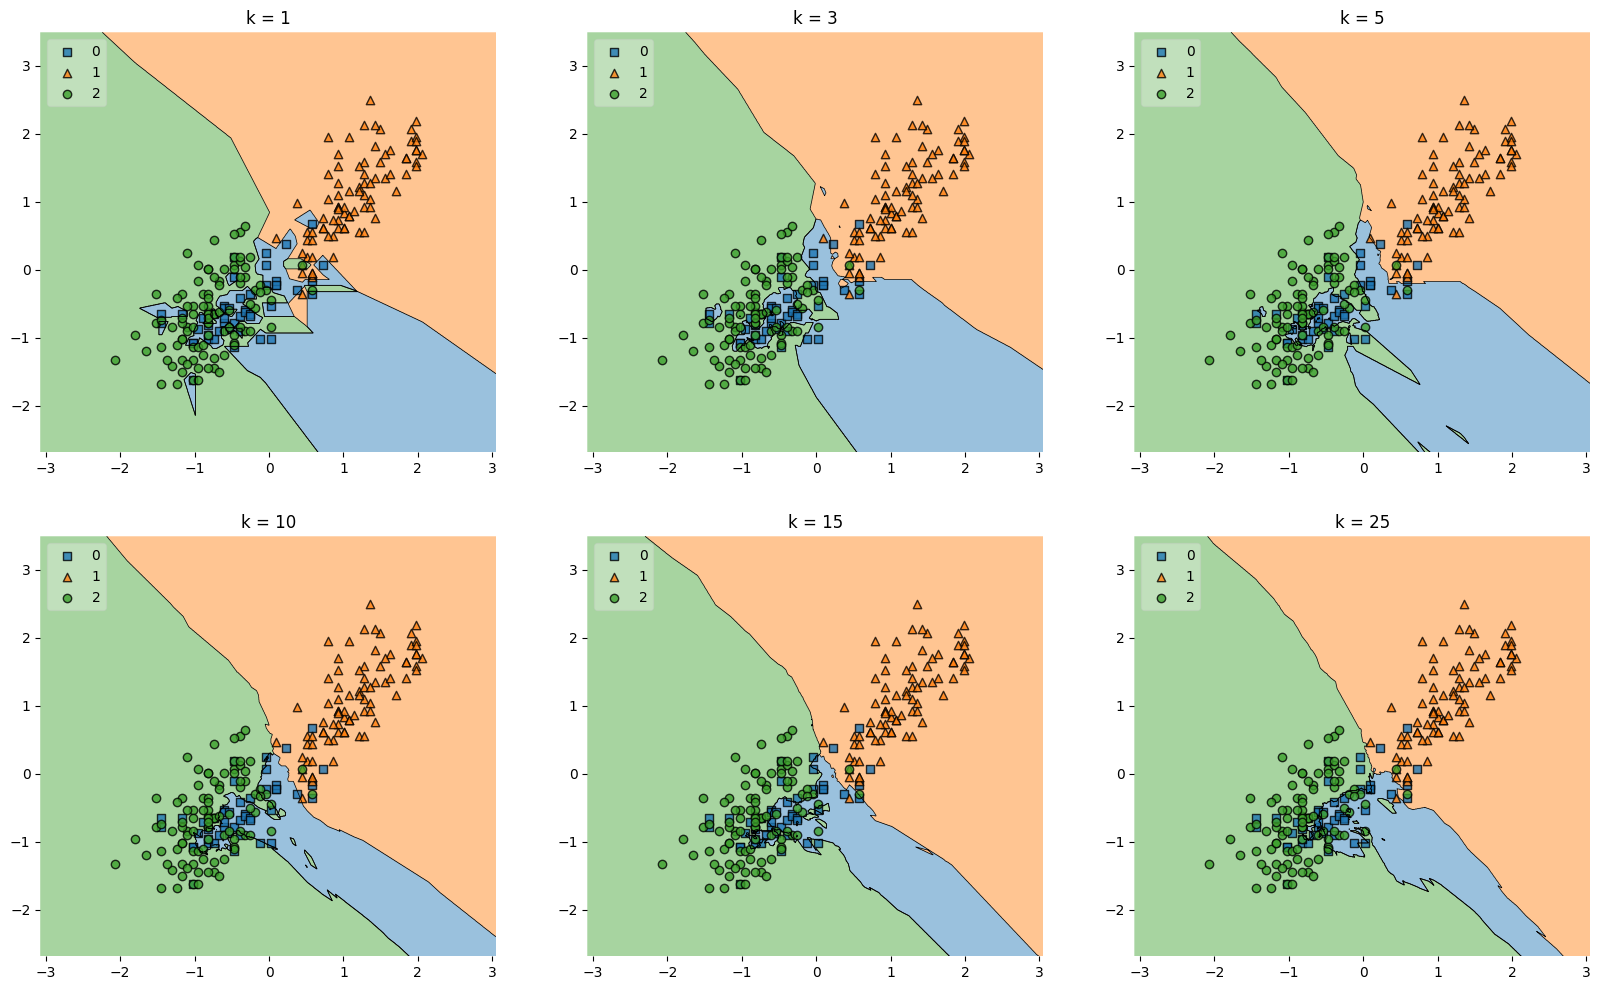

In [ ]:
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

for i in range(6):
  plot_decision_regions(X_train_norm, y_train.to_numpy().astype(np.int_), clf=models[i], legend=2, ax = axes[i//3, i%3])
  axes[i//3, i%3].set_title(f"k = {neighbours[i]}")

plt.show()

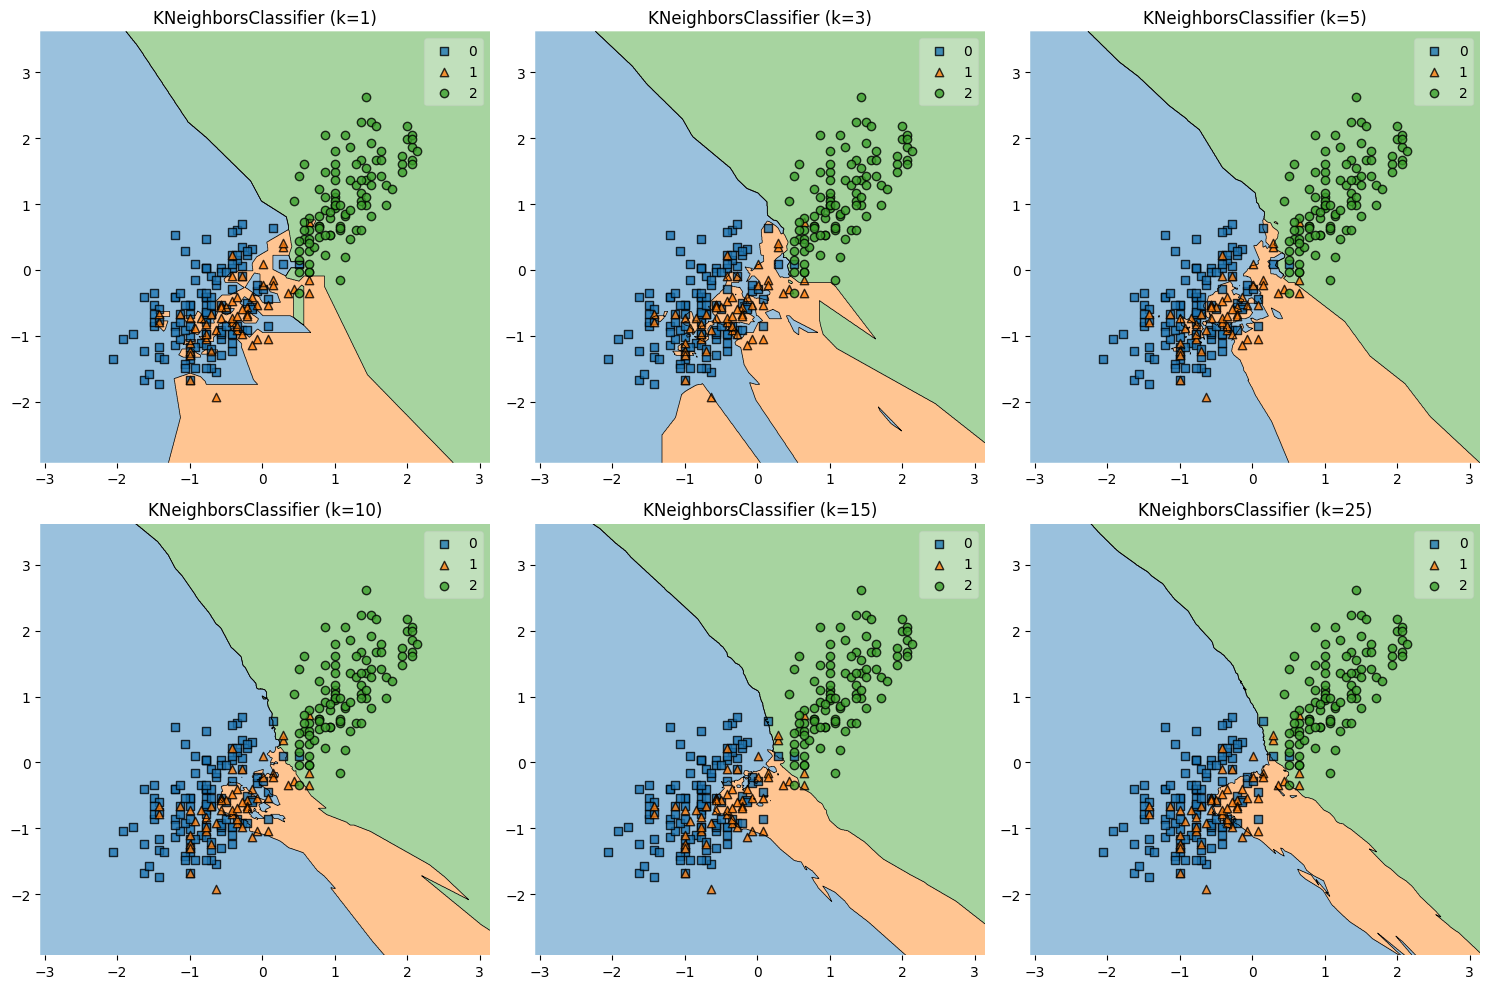

In [ ]:
# В примере пингвинчики закодированы в алфавитном порядке, ваш вариант будет отличаться.

**Задача 1.6 (0.5 балла)** Прокомментируйте результаты, полученные в задачах 1.3 и 1.5. Какое число соседей оптимально использовать для обучения классификатора? Поясните ваш выбор при помощи описания геометрии данных и получаемой решающей поверхности. Какие из результатов явно говорят о переобучении модели? Почему?

Основываясь на задании 1.3, можно сказать, что с увеличением соседей доля верных ответов уменьшается на тренировочной выборке и есть тренд на увеличение на тестовой. Также при k = 1, 3, 5 есть достаточно большая разница между результатом на тренировочной выборке и тестовой. Это один из признаков переобучения. Также графики при таком количестве соседей получились рваными и с островками, что тоже свидетельствует о переобучении.
А лучше всего взять количество соседей равное 25, там зафиксирована наибольшая точность на тесте, а также график наиболее плавный

### Задание 2. KNN своими руками. 2,5 балла

**Задача 2.1 (2 балла)** В данном задании мы попробуем реализовать алгоритм KNN своими руками, делать мы будем KNN именно для классификации.

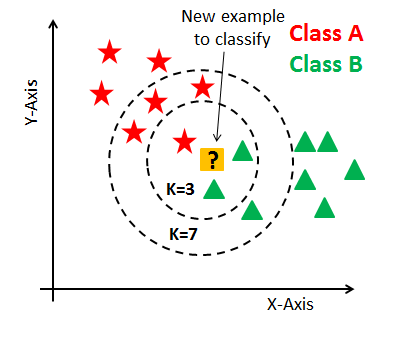

Рекомендации по реализации:
- Используйте `numpy` для представления данных в виде массивов, чтобы минимизировать преобразования.
- Избегайте циклов по всем объектам, по возможности используйте векторизированные операции.
- Обратите внимание на методы [np.linalg.norm()](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html) и [np.argsort()](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html), а также на класс `collections.Counter`.
- Особый плюс, если учтёте обработку возможных ошибок.

In [5]:
np.array([[1, 0], [1, 1], [0, 0]])

array([[1, 0],
       [1, 1],
       [0, 0]])

In [111]:
import numpy as np
from collections import Counter
from scipy import stats

class KNN:
    def __init__(self, k:int):
        if k <= 0:
          raise ValueError("k должен быть больше 0")
        self.k = k
        self.X = None
        self.y = None

    def fit(self, X, y):
      if X.ndim != 2 or y.ndim !=1:
        raise ValueError("Неправильные размерности входных данных")
      if len(X) != len(y):
        raise ValueError("Разное количество данных")
      if self.k > len(X):
        raise ValueError("Количество объектов должно быть больше k")
      self.X = X
      self.y = y


    def predict(self, X):
      if self.X is None or self.y is None:
        raise ValueError("Модель не обучена")
      if X.ndim != 2:
            raise ValueError("Неправильные размерности входных данных")
      if X.shape[1] != self.X.shape[1]:
            raise ValueError("Неправильное количество признаков")

      distances = np.linalg.norm(X[:, np.newaxis, :] - self.X[np.newaxis, :, :], axis = 2)
      ids = np.argsort(distances, axis=1)[:, :self.k]

      labels = self.y[ids]

      return stats.mode(labels, axis=1).mode

    def count_distance(self, x, y):

      if x.ndim != 1 or y.ndim !=1:
        raise ValueError("Неправильные размерности входных данных")
      if len(X) != len(y):
        raise ValueError("Разное количество признаков")

      return np.linalg.norm(x - y)[0]

      pass

In [86]:
# Не меняйте файл!
def test_knn(KNN):
  knn = KNN(k=1)
  X_train =  np.array([[1, 1], [2, 2]])
  y_train =  np.array([0, 1])
  X_test =  np.array([[1.5, 1.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [0]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[9.5, 9.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5.5, 5.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[15, 15]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5, 5], [2, 2]])
  knn.fit(X_train, y_train)
  assert all(knn.predict(X_test) == [1, 0])

In [87]:
# Если тесты эти пройдены, то все верно!
test_knn(KNN)

**Задача 2.2 (0.5 балла)** Протестируйте ваш алгоритм на данных о пингвинах. Выведите лучший получившийся результат на тестовой выборке.

In [116]:
max_k = -1
max_ac = 0
for i in range(1, 100):
   knn = KNN(k=i)
   knn.fit(X_train_norm, y_train.to_numpy())
   accuracy = np.mean(y_test.to_numpy() == knn.predict(X_test_norm))
   if (max_ac < accuracy):
    max_ac = accuracy
    max_k = i

print(f"k={max_k}: accuracy - {max_ac}")

k=32: accuracy - 0.7959183673469388


### Задание 3: Линейная регрессия.

В этом задании мы рассмотрим различные аспекты построения линейной модели. Мы будем работать с одним из классических наборов данных в статистике, содержащим информацию о бриллиантах. Описание можно посмотреть [здесь](https://www.kaggle.com/shivam2503/diamonds).

In [6]:
data = pd.read_csv('diamonds.csv')
data.head(5)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Мы будем решать задачу предсказания цены бриллианта `price` в зависимости от его характеристик.

**Задача 3.1 (0.2 балла)** Есть ли в наборе данных пропущенные значения? Если да, удалите их.
Есть ли в наборе данных бессмысленные столбцы (признаки, не несущие дополнительной информации)? Если да, то удалите их.

In [121]:
data.isna().sum()

,0
Unnamed: 0,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0


In [7]:
data = data.drop(columns = ['Unnamed: 0'])

Пропусков нет. Все столбцы, кроме unnamed 0 несут смысловую настройку

**Задача 3.2 (0.2 балла)** Линейная регрессия основана на предположении о линейной связи между признаками и целевой переменной, а потому перед выбором переменных для включения в модель имеет смысл проверить, насколько эта связь выполняется. Для следующих пунктов нам также потребуются выборочные корреляции между признаками. Постройте матрицу корреляций между всеми вещественными признаками и целевой переменной (то есть в этой матрице будет $k+1$ строка, где $k$ – количество вещественных признаков).

Какие вещественные признаки имеют наибольшую корреляцию с целевой переменной?

<Axes: >

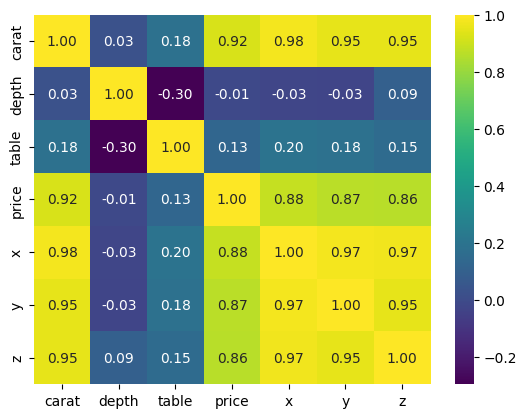

In [134]:
import seaborn as sns

sns.heatmap(data.loc[:, ['carat',	'depth',	'table',	'price',	'x', 'y',	'z']].corr(), annot = True, fmt=".2f", cmap="viridis")

Цена чуть ли не полностью зависит от размера бриллианта. Около 0.9 есть корреляция с carat, x, y, z

**Задача 3.3 (0.2 балла)** Так как линейная модель складывает значения признаков с некоторыми весами, нам нужно аккуратно обработать категориальные признаки. Закодируйте категориальные признаки методом OneHot-кодирования (`pd.get_dummies()` или `OneHotEncoder` из `sklearn`).

In [8]:
data_dum = pd.get_dummies(data, columns = ['cut', 'color', 'clarity'], drop_first=True)

**Задача 3.4 (0.2 балла)** Разделите выборку на тренировочную и тестовую. Долю тестовой выборки укажите равной 0.3.

In [10]:
X = data_dum.drop(columns = ['price'])
y = data_dum.loc[:, ['price']]


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 228)

**Задача 3.5 (0.3 балла)** Зачастую при использовании линейных моделей вещественные признаки масштабируются. При этом оценки коэффициентов теряют прямую статистическую интерпретацию ("при увеличении $X_1$ на 1, $y$ увеличивается на $w_1$"), но приобретают свойства, полезные в задачах машинного обучения. В этой задаче стандартизируйте вещественные признаки в тренировочной и тестовой выборках с помощью `StandardScaler`.

Объясните, как это повлияет на интерпретацию коэффициентов линейной регрессии.

In [16]:
real_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']
X_train_norm = X_train.copy()
X_test_norm = X_test.copy()

scaler = sklearn.preprocessing.StandardScaler()
scaler.fit(X_train[real_cols])
X_train_norm[real_cols] = scaler.transform(X_train_norm[real_cols])
X_test_norm[real_cols] = scaler.transform(X_test_norm[real_cols])

Благодаря этому все параметры приведены примерно в один диапазон значений, а значит теперь, смотря на веса можно интерпреетировать, что влияет больше, а что меньше

**Задача 3.6 (0.2 балла)** Оцените линейную регрессию на тренировочной выборке. Выведите среднеквадратичную ошибку на тренировочной и тестовой выборках.

In [83]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_norm, y_train)

LinearRegression()

In [84]:
from sklearn.metrics import mean_absolute_error as MAE, mean_squared_error as MSE

print("Train MSE:", MSE(lr.predict(X_train_norm), y_train))

print("Test MSE:", MSE(lr.predict(X_test_norm), y_test))

Train MSE: 1277369.714539707
Test MSE: 1276274.6159733103


**Задача 3.7 (0.3 балла)** Изучите [документацию](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) модуля `LinearRegression` и выведите полученные оценки коэффициентов. Назовите вещественные переменные, оценки коэффициентов которых по модулю на порядок превышают оценки прочих вещественных переменных.

In [19]:
for i in range(len(X_train_norm.columns)):
  print(X_train_norm.columns[i], lr.coef_[0][i])

carat 5335.133617897235
depth -79.62069059608473
table -46.58230877845094
x -1058.5531975650192
y 2.7307415171332856
z -104.0843601761561
cut_Good 619.1334320453941
cut_Ideal 881.8135026523275
cut_Premium 780.3031076654024
cut_Very Good 752.9870080871736
color_E -202.96276031688873
color_F -263.5989893270756
color_G -485.0548763901627
color_H -965.6184925489194
color_I -1476.1813583550238
color_J -2370.003308093931
clarity_IF 5333.84656945749
clarity_SI1 3630.239409696432
clarity_SI2 2677.7135728810736
clarity_VS1 4561.904664567984
clarity_VS2 4244.339924699971
clarity_VVS1 4978.4561264082995
clarity_VVS2 4933.233199974008


На порядок с огромным отрывом превосходит значение carat, что было предсказуемо. Также на порядок превосходит x причём отрицательно. Но в целом всё это выглядит странно, вероятно, что из-за очень сильной корреляции между x и carat, carat перетянул на себя все веса и X стал баже отрицательно влиять

**Задача 3.8 (0.5 балла)** Как можно заметить из анализа корреляционной матрицы в задаче 3.3, между некоторыми признаками имеется сильная корреляция, что может быть индикатором проблемы *мультиколлинеарности*. Различия в порядке коэффициентов, выявленные в предыдущей задаче также намекают на её присутствие. Как известно, для решения этой проблемы можно либо исключить некоторые признаки из модели, либо использовать регуляризацию. Мы воспользуемся вторым вариантом.

Вспомним, что смысл регуляризации заключается в том, чтобы изменить функцию потерь так, чтобы устранить проблемы, появляющиеся из-за мультиколлинеарности. При L1-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\sum_{i=1}^k|w_i|
$$

Такая модель называется Lasso-регрессией.

При L2-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\|w\|^2
$$

Такая модель называется Ridge-регрессией.

Обучите Lasso-регрессию и Ridge-регрессию, установив гиперпараметр регуляризации равным 10. Для этого используйте модули `Lasso` и `Ridge` из `sklearn`. Сильно ли уменьшились веса? Сделайте вывод о том, насколько сильно проблема мультиколлинеарности проявлялась в изначальной регрессии.

In [81]:
from sklearn.linear_model import Lasso, Ridge
alpha = 10

las_lr = Lasso(alpha)
las_lr.fit(X_train_norm, y_train)

Lasso(alpha=10)

In [82]:
print("Train MSE:", MSE(las_lr.predict(X_train_norm), y_train))

print("Test MSE:", MSE(las_lr.predict(X_test_norm), y_test))

Train MSE: 1512212.8915489444
Test MSE: 1502123.528503551


In [32]:
for i in range(len(X_train_norm.columns)):
  print(X_train_norm.columns[i], las_lr.coef_[i])

carat 4772.4172195205065
depth -150.50521333461123
table -92.98618010182473
x -707.9925106644845
y -0.0
z -15.805295847335922
cut_Good -0.0
cut_Ideal 195.99450660775722
cut_Premium 68.76686406025509
cut_Very Good 87.96186995931058
color_E 0.0
color_F -0.0
color_G -127.80611473786105
color_H -599.8637388292543
color_I -1017.4292102619498
color_J -1804.7558619166705
clarity_IF 1332.2469105074913
clarity_SI1 0.0
clarity_SI2 -792.5222493648383
clarity_VS1 844.3361798828646
clarity_VS2 593.9555080579294
clarity_VVS1 1156.9577591728635
clarity_VVS2 1183.4138994545863


In [54]:
rid_lr = Ridge(alpha)
rid_lr.fit(X_train_norm, y_train)

Ridge(alpha=10)

In [55]:
print("Train MSE:", MSE(rid_lr.predict(X_train_norm), y_train))

print("Test MSE:", MSE(rid_lr.predict(X_test_norm), y_test))

Train MSE: 1281324.9692750783
Test MSE: 1280911.1249638277


In [56]:
for i in range(len(X_train_norm.columns)):
  print(X_train_norm.columns[i], rid_lr.coef_[i])

carat 5285.275747616697
depth -83.11732179127092
table -49.114751742165055
x -1024.4484334817723
y 3.139368551442935
z -101.09668943116854
cut_Good 642.4153235211544
cut_Ideal 910.3727048284761
cut_Premium 804.7310044992912
cut_Very Good 782.9829851899243
color_E -191.16230810089368
color_F -250.05613193519466
color_G -467.4087279656718
color_H -948.4588341803848
color_I -1451.388297010566
color_J -2335.6434209658496
clarity_IF 4755.067470632009
clarity_SI1 3097.069564184203
clarity_SI2 2152.3491874912834
clarity_VS1 4019.4915215707374
clarity_VS2 3707.465211192881
clarity_VVS1 4421.681771115899
clarity_VVS2 4384.245126597291


Lasso достаточно сильно порезало коэффициенты, а также занулило некоторые. Ridge же почти не изменило их. Это говорит о том, что мультиколлинеарность была, так как лассо занулило некоторые признаки, но не была огромной проблемой, так как Ridge совсем слабо подкорректировало веса. Но зато метрики улучшились очень значительно

**Задача 3.9 (0.5 балла)** Как обсуждалось на семинарах, Lasso-регрессию можно использовать для отбора наиболее информативных признаков. Для следующих значений параметра регуляриазции $\alpha$: 0.1, 1, 10, 100, 200 –  обучите Lasso- и Ridge-регрессии и постройте график измненения евклидовой нормы весов (`np.linalg.norm()` от вектора оценок коэффициентов) в зависимости от параметра $\alpha$. Как известно, норма является численной характеристикой величины вектора, а потому по норме можно судить о том, насколько большие элементы содержит вектор оценок коэффициентов.

Какой метод сильнее снижает норму коэффициентов? Поясните, почему Lasso-регрессию часто используют для отбора признаков.

In [57]:
alphas = [0.1, 1, 10, 100, 200]

lasso_norm = []
ridge_norm = []

for a in alphas:

  las_lr = Lasso(a)
  las_lr.fit(X_train_norm, y_train)
  lasso_norm.append(np.linalg.norm(las_lr.coef_))

  rid_lr = Ridge(a)
  rid_lr.fit(X_train_norm, y_train)
  ridge_norm.append(np.linalg.norm(rid_lr.coef_))

<Axes: >

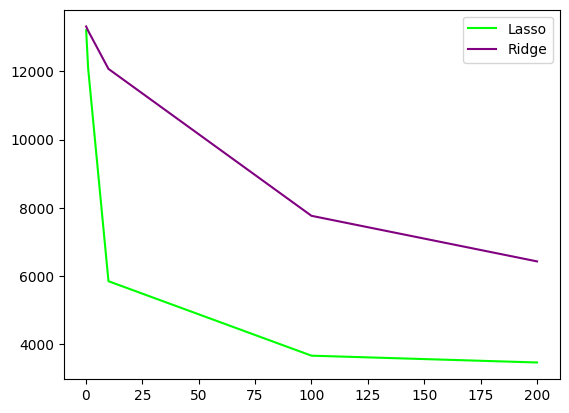

In [64]:
import seaborn as sns

sns.lineplot(x = alphas, y = lasso_norm, color = 'lime', label = 'Lasso')
sns.lineplot(x = alphas, y = ridge_norm, color = 'purple', label = 'Ridge')


Лассо чуть ли не в 2 раза сильнее режет норму весов, а следовательно он лучше борется с большими признакими. Также его использую, для выявления ненужных признаков из-за того, что он с большей вероятностью обнулит невлиятельные признаки из-за своей эффективности

**Задача 3.10 (0.5 балла)**
В зависимости от значения параметра $\alpha$ в Lasso-регрессии зануляются разные оценки коэффициентов. Оптимальное значение $\alpha$ можно подобрать, например, при помощи кросс-валидации по тренировочной выборке.

Для проведения кросс-валидации можно использовать модуль `LassoCV`. Этот модуль принимает список значений $\alpha$ (параметр `alphas`) и при обучении проводит кросс-валидацию для каждого значения из этого списка, сохраняя MSE на каждом участке кросс-валидации (количество участков – параметр `cv`) в матрицу ошибок (то есть итоговая матрица будет иметь размер `len(alphas)` $\times$ `cv`). После обучения модели матрицу ошибок можно получить, обратившись к атрибуту `.mse_path_`.

Заметим, что модель может использовать $\alpha$ не в том порядке, в котором вы подаёте их в функцию: для определения порядка используйте атрибут `.alphas_` Установите количество участков для кросс-валидации (параметр `cv`) равным 5.

Усредните ошибки для каждого значения $\alpha$ (то есть по строкам матрицы ошибок) и выберите то значение, которое даёт наибольшее качество.

In [69]:
from sklearn.linear_model import LassoCV

lassoCV = LassoCV(alphas = alphas, cv = 5)
lassoCV.fit(X_train_norm, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:1664: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LassoCV(alphas=[0.1, 1, 10, 100, 200], cv=5)

In [75]:
df = pd.DataFrame({'Alphas': lassoCV.alphas_, 'MSE_mean': lassoCV.mse_path_.mean(axis = 1)})

In [76]:
df

,Alphas,MSE_mean
0,200.0,2.454794e+06
1,100.0,2.246350e+06
2,10.0,1.512849e+06
3,1.0,1.285282e+06
4,0.1,1.281012e+06


Наименьшая альфа при наименьшем коэффициете получилась. MSE ~ 1280000

**Задача 3.11 (0.5 балла)** Обучите итоговую Lasso-регрессию с выбранным параметром $\alpha$ на тренировочной выборке. Выведите полученные коэффициенты и прокомментируйте, какие признаки оказались неинформативными, а какие – наиболее информативными. Приведите возможное смысловое объяснение этого результата.

In [77]:
alpha = 0.1

las_lr = Lasso(alpha)
las_lr.fit(X_train_norm, y_train)

for i in range(len(X_train_norm.columns)):
  print(X_train_norm.columns[i], las_lr.coef_[i])

carat 5329.456252894726
depth -80.85247372716859
table -47.19113354811621
x -1054.677446346283
y 0.16961274518670058
z -101.1856212331266
cut_Good 609.2382913477722
cut_Ideal 872.2931077642263
cut_Premium 770.5431211368832
cut_Very Good 743.8653250380887
color_E -197.667163044553
color_F -258.2287797583599
color_G -479.2856335235438
color_H -959.7949645408743
color_I -1469.3603135426806
color_J -2362.152115367957
clarity_IF 5279.479618017523
clarity_SI1 3579.979719890176
clarity_SI2 2627.8684298528087
clarity_VS1 4510.54923270941
clarity_VS2 4193.7382636483235
clarity_VVS1 4925.884346830061
clarity_VVS2 4881.475869521145


Коэффициент регуляризации был очень маленький, поэтому почти ничего не занулилось. Но всё же некоторые выводы можно сделать:  коэффициент y находится около 0, а признаки depth, table и z имеют небольшие коэффициенты, поэтому их вклад в модель существенно слабее. А наиболее влиятельными оказались carat, clarity и color. Ну оно и изначально было понятно, что чем больше, прозрачнее бриллиант, а также если он имеет необычный цвет, то тем он дороже.

**Задача 3.12 (0.4 балла)** Сделайте предсказания обученной Lasso-регрессии на тестовой выборке и сравните среднеквадратичную ошибку с ошибкой обычной линейной регрессии из задачи 3.7. Какую модель лучше использовать для предсказаний? Приведите возможное объяснение, почему одна модель оказалась лучше другой.

In [80]:
print("Test MSE Lasso:", MSE(rid_lr.predict(X_test_norm), y_test))

Test MSE Lasso: 1437018.3426579437


В данном случае обычная регрессия работает лучше, чем та, что с регуляризацией. Возможно, здесь мультиколлинеарность не была большой проблемой, а регуляризация заставила срезать некоторые коэффициенты, что и подпортило результат